Training data: (125973, 43)
Testing data: (22544, 43)

Accuracy: 77.07 %

Classification Report:
              precision    recall  f1-score   support

      Normal       0.66      0.97      0.78      9711
      Attack       0.97      0.62      0.75     12833

    accuracy                           0.77     22544
   macro avg       0.81      0.80      0.77     22544
weighted avg       0.83      0.77      0.77     22544



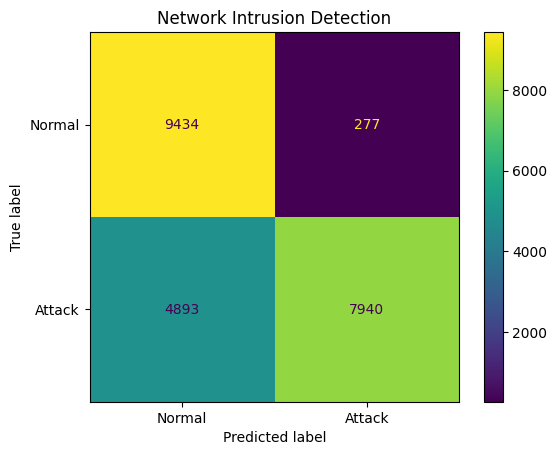

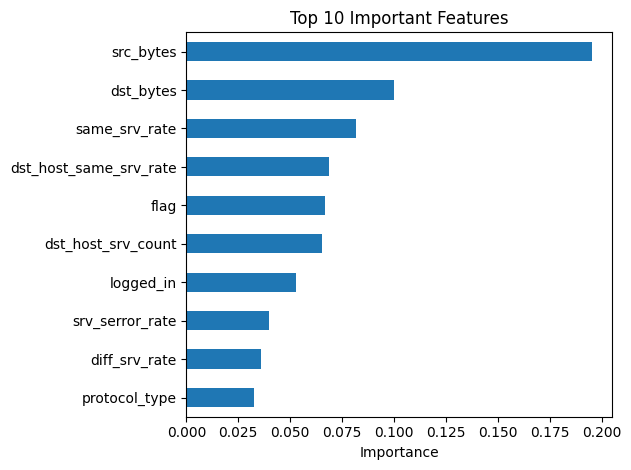


Sample Predictions:
    Actual Predicted
0   Attack    Attack
1   Attack    Attack
2   Normal    Normal
3   Attack    Attack
4   Attack    Normal
5   Normal    Normal
6   Normal    Normal
7   Attack    Normal
8   Normal    Normal
9   Attack    Normal
10  Attack    Normal
11  Normal    Normal
12  Attack    Attack
13  Attack    Attack
14  Normal    Normal
15  Normal    Normal
16  Normal    Normal
17  Normal    Normal
18  Normal    Normal
19  Attack    Attack

Model saved successfully.


In [2]:
import pandas as pd
import os
import urllib.request
import matplotlib.pyplot as plt
import joblib

from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

train_url = "https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTrain%2B.txt"
test_url = "https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTest%2B.txt"

train_file = "KDDTrain+.txt"
test_file = "KDDTest+.txt"

if not os.path.exists(train_file):
    urllib.request.urlretrieve(train_url, train_file)

if not os.path.exists(test_file):
    urllib.request.urlretrieve(test_url, test_file)

columns = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
    'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in',
    'num_compromised', 'root_shell', 'su_attempted', 'num_root',
    'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds',
    'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate',
    'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
    'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
    'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate',
    'dst_host_serror_rate', 'dst_host_srv_serror_rate',
    'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'attack', 'difficulty'
]

train = pd.read_csv(train_file, names=columns)
test = pd.read_csv(test_file, names=columns)

print("Training data:", train.shape)
print("Testing data:", test.shape)


train['label'] = train['attack'].apply(lambda x: 0 if x == 'normal' else 1)
test['label'] = test['attack'].apply(lambda x: 0 if x == 'normal' else 1)

train.drop(['attack', 'difficulty'], axis=1, inplace=True)
test.drop(['attack', 'difficulty'], axis=1, inplace=True)

features = pd.concat([
    train.drop('label', axis=1),
    test.drop('label', axis=1)
], ignore_index=True)

encoders = {}

for col in ['protocol_type', 'service', 'flag']:
    le = LabelEncoder()
    features[col] = le.fit_transform(features[col])
    encoders[col] = le

X_train = features.iloc[:len(train)]
X_test = features.iloc[len(train):]

y_train = train['label']
y_test = test['label']

model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

predictions = model.predict(X_test)

print("\nAccuracy:", round(accuracy_score(y_test, predictions) * 100, 2), "%")
print("\nClassification Report:")
print(classification_report(y_test, predictions, target_names=['Normal', 'Attack']))

cm = confusion_matrix(y_test, predictions)
ConfusionMatrixDisplay(cm, display_labels=['Normal', 'Attack']).plot()
plt.title("Network Intrusion Detection")
plt.show()

importance = pd.Series(model.feature_importances_, index=X_train.columns)
importance.nlargest(10).sort_values().plot(kind='barh')
plt.title("Top 10 Important Features")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

result = pd.DataFrame({
    'Actual': y_test.iloc[:20].map({0: 'Normal', 1: 'Attack'}).values,
    'Predicted': pd.Series(predictions[:20]).map({0: 'Normal', 1: 'Attack'}).values
})

print("\nSample Predictions:")
print(result)

joblib.dump(model, "intrusion_detection_model.pkl")
joblib.dump(encoders, "encoders.pkl")

print("\nModel saved successfully.")